In [3]:
import pandas as pd

train = pd.read_csv('train.csv')
train.shape

(1460, 81)

In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.isnull().sum().sort_values(ascending=False).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [6]:
# Columns where NaN genuinely means "this feature doesn't exist" - fill with "None"
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in none_cols:
    train[col] = train[col].fillna('None')

In [7]:
# GarageYrBlt: if no garage, there's no "year built" - fill with 0 as a placeholder
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)

# MasVnrArea: if no masonry veneer, area is naturally 0
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)

In [8]:
# LotFrontage: a real physical measurement, genuinely missing sometimes - fill with the median
train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())

# Electrical: just 1 row genuinely missing - simplest to drop that single row
train = train.dropna(subset=['Electrical'])

In [9]:
train.isnull().sum().sort_values(ascending=False).head(10)

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
Alley,0
LotShape,0
LandContour,0
Utilities,0


In [12]:
#after dropping "Electrical" row, we will check the shape of the data.
train.shape

(1459, 81)

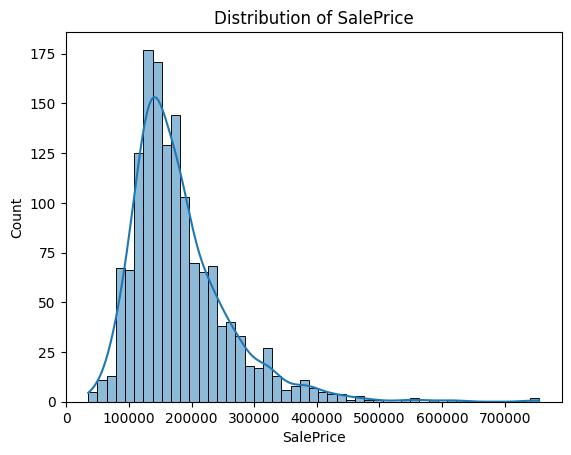

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(train['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.show()

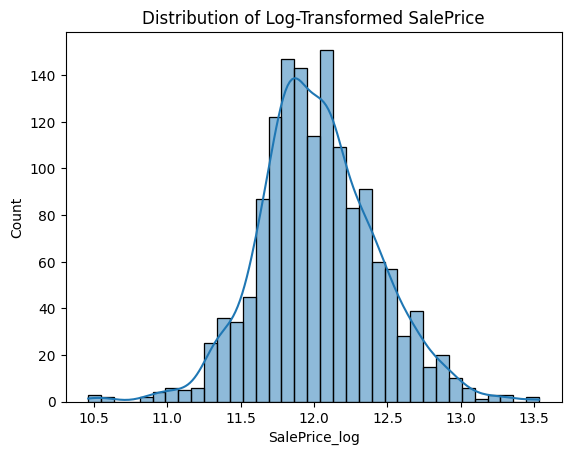

In [14]:
import numpy as np

train['SalePrice_log'] = np.log1p(train['SalePrice'])

sns.histplot(train['SalePrice_log'], kde=True)
plt.title('Distribution of Log-Transformed SalePrice')
plt.show()

In [15]:
train = train.drop(columns=['Id'])

In [16]:
train_encoded = pd.get_dummies(train, drop_first=True)
train_encoded.shape

(1459, 261)

In [17]:
X = train_encoded.drop(columns=['SalePrice', 'SalePrice_log'])
y = train_encoded['SalePrice_log']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

MAE: 0.09531741150169923
RMSE: 0.18340010332710882
R²: 0.804721998633976


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf}")
print(f"RMSE: {rmse_rf}")
print(f"R²: {r2_rf}")

MAE: 0.0983610208680248
RMSE: 0.14437802057565965
R²: 0.8789802263947589


In [22]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15)

,0
OverallQual,0.542052
GrLivArea,0.102017
TotalBsmtSF,0.045468
GarageCars,0.042164
GarageArea,0.030296
BsmtFinSF1,0.026737
1stFlrSF,0.018069
YearBuilt,0.017251
LotArea,0.016543
OverallCond,0.009526


In [23]:
test = pd.read_csv('test.csv')
test_ids = test['Id']

# Apply the same "None" fill for features that don't exist
for col in none_cols:
    test[col] = test[col].fillna('None')

# Same numeric fills
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)
test['LotFrontage'] = test['LotFrontage'].fillna(train['LotFrontage'].median())

In [24]:
test['Electrical'] = test['Electrical'].fillna(train['Electrical'].mode()[0])

In [25]:
test.isnull().sum().sort_values(ascending=False).head(15)

,0
MSZoning,4
Utilities,2
BsmtHalfBath,2
BsmtFullBath,2
Functional,2
GarageCars,1
BsmtUnfSF,1
BsmtFinSF2,1
Exterior2nd,1
BsmtFinSF1,1


In [26]:
bsmt_garage_numeric = ['BsmtHalfBath', 'BsmtFullBath', 'GarageCars', 'BsmtUnfSF',
                        'BsmtFinSF2', 'BsmtFinSF1', 'TotalBsmtSF', 'GarageArea']

for col in bsmt_garage_numeric:
    test[col] = test[col].fillna(0)

In [27]:
categorical_fill_mode = ['MSZoning', 'Utilities', 'Functional', 'Exterior1st',
                          'Exterior2nd', 'KitchenQual', 'SaleType']

for col in categorical_fill_mode:
    test[col] = test[col].fillna(train[col].mode()[0])

In [28]:
test.isnull().sum().sort_values(ascending=False).head(5)

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0


In [29]:
test_encoded = pd.get_dummies(test.drop(columns=['Id']), drop_first=True)

X_train_aligned, test_aligned = X.align(test_encoded, join='left', axis=1, fill_value=0)

In [30]:
print(X_train_aligned.shape)
print(test_aligned.shape)

(1459, 259)
(1459, 259)


In [31]:
test_predictions_log = rf_model.predict(test_aligned)

In [32]:
import numpy as np

test_predictions = np.expm1(test_predictions_log)

In [33]:
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_predictions
})

submission.to_csv('submission.csv', index=False)

In [34]:
submission.head()

,Id,SalePrice
0,1461,126656.592286
1,1462,152609.103157
2,1463,177815.922214
3,1464,179893.026888
4,1465,197083.263512
